In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

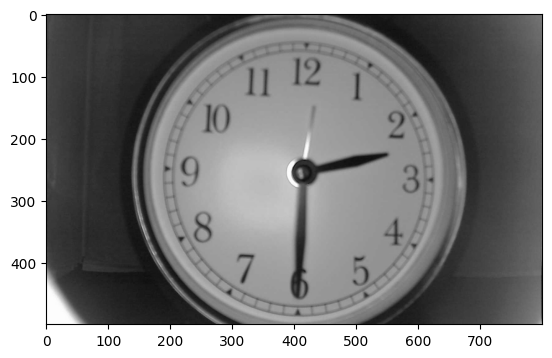

In [ ]:
im = cv.cvtColor(cv.imread("../data-resampled/clock_0200.png"), cv.COLOR_BGR2RGB)
plt.imshow(im)
plt.show()

In [ ]:
# ### Removing reflections


# img_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)

# h,s,v = cv.split(img_hsv)

# ## Take V vals

# v = img_hsv[:,:,2]

# thres_1 = cv.adaptiveThreshold(np.array(v-255), 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 17)


# thres_in = np.array(255 - thres_1)

# thres_2 = cv.adaptiveThreshold(thres_in, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 9)


# sub = cv.subtract(thres_2, thres_in)


# b = cv.merge([sub, sub, sub])

# blr = cv.medianBlur(im, 15)

# w = np.where(b == (0,0,0), blr, im)

# plt.imshow(w)





### Convertir a gris

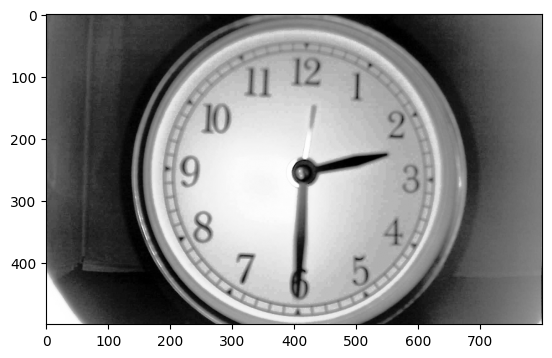

In [ ]:
gray = cv.cvtColor(im, cv.COLOR_RGB2GRAY)

gray_eq = cv.equalizeHist(gray)

plt.imshow(gray_eq, cmap="gray")

# Binarización

In [ ]:
squared = gray - 255


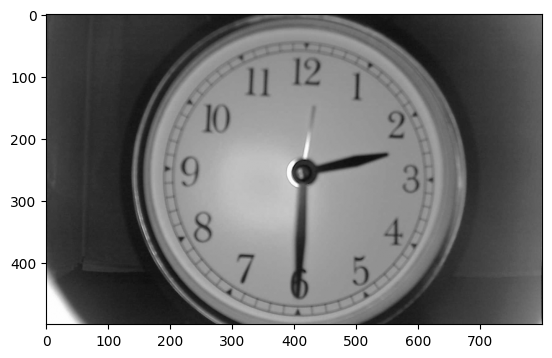

In [ ]:
plt.imshow(squared, cmap="gray")
plt.show()

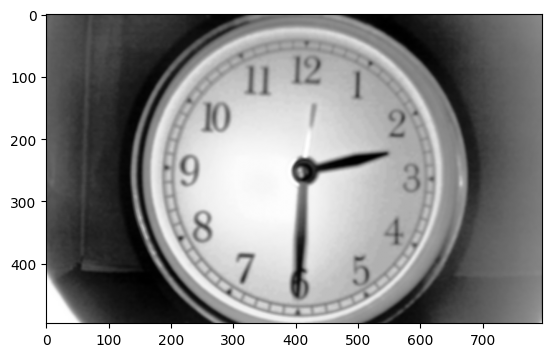

In [ ]:
def conv2d(img, kernel, bias):
    m,n = kernel.shape
    if(m == n):
        x,y = img.shape
        x = (x - m) + 1
        y = (y - n) + 1
        n_img = np.zeros((x,y))
        for i in range(x):
            for j in range(y):
                n_img[i,j] = np.sum(img[i:i+m, j:j+m]*kernel) + bias
    return n_img

kernel = (1/9) * np.array([
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
])


blurred_img = conv2d(gray_eq, kernel, 2)

plt.imshow(blurred_img, cmap="gray")
plt.show()

# Hallar circulo usando hough


circles = cv.HoughCircles(blurred_img.astype(np.uint8), cv.HOUGH_GRADIENT, 1, 20, param1=10, param2=50, minRadius=220, maxRadius=225)
circles

In [ ]:
circles = cv.HoughCircles(blurred_img.astype(np.uint8), cv.HOUGH_GRADIENT, 1, 20, param1=10, param2=50, minRadius=214, maxRadius=225)
circles

array([[[393.5, 272.5, 224.4]]], dtype=float32)

In [ ]:
canny_copy = blurred_img.copy()
for c in circles[0]:
    (x,y,r) = c
    x = int(x)
    y = int(y)
    r = int(r)
    cv.circle(canny_copy, (x, y), r, (255, 255, 255), 4)

    

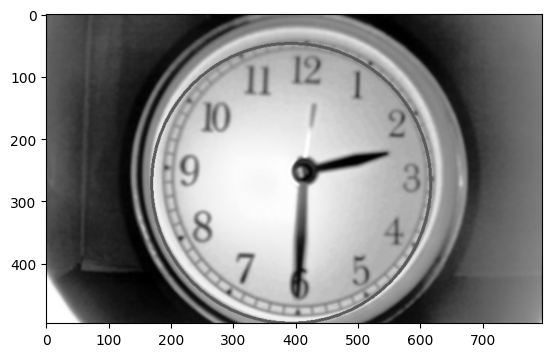

In [ ]:
plt.imshow(canny_copy, cmap="gray")
plt.show()

### Segmentar manecillas

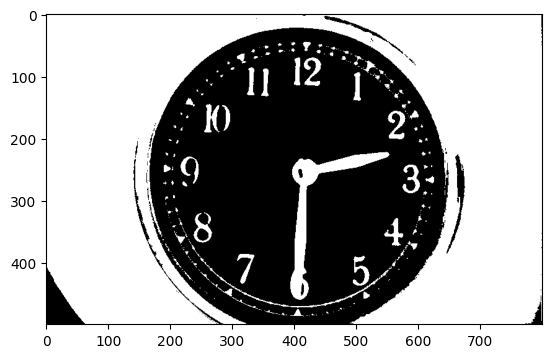

In [ ]:
def umbralization(img,t, option1, option2):
    M,N = img.shape

    result = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            result[i,j] = option1 if img[i,j]  <= t  else option2


    return result



umbralized = 255 - umbralization(gray,120, 0, 255) 
plt.imshow(umbralized, cmap="gray")
plt.show()

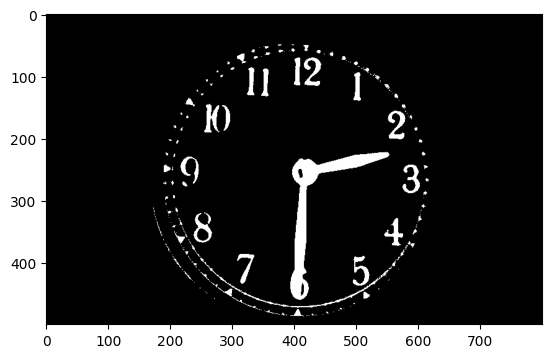

In [ ]:
x_centro = int(circles[0][0][0])
y_centro = int(circles [0][0][1])
radio = int(circles[0][0][2])

(M,N) = umbralized.shape

mask = np.ones((M,N))
result = np.zeros((M,N))


for x in range(M):
    for y in range(N):
        distance = np.sqrt((y-x_centro)**2 + (x-y_centro)**2)
        mask[x,y] = True if distance <= radio else False


for x in range(M):
    for y in range(N):
        result[x,y] = umbralized[x,y] if mask[x,y] else 0


plt.imshow(result, cmap="gray")
plt.show()


In [ ]:
lines = cv.HoughLinesP(result.astype(np.uint8), rho=1, theta=np.pi/180, threshold=100,
                        minLineLength=100, maxLineGap=0)

In [ ]:
lines_clock = np.zeros(result.shape)

for x in lines:
    x1, y1, x2, y2 = x[0]
    cv.line(lines_clock, (x1, y1), (x2, y2), (255, 255, 255), 2)


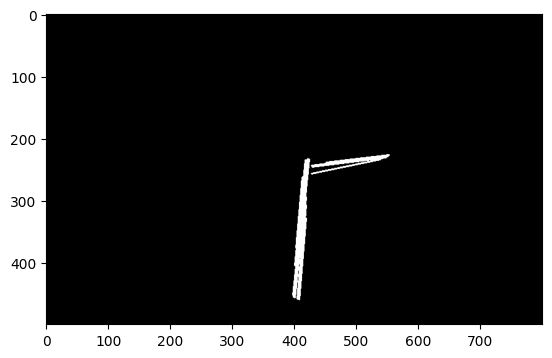

In [ ]:
plt.imshow(lines_clock, cmap="gray")

In [ ]:
x,y = np.where(lines_clock > 0)

distance = np.sqrt((x-y_centro)**2 + (y-x_centro)**2)


In [ ]:
## Maxima distancia desde el centro

manecilla_grande_idx = np.argmax(distance)


distance[manecilla_grande_idx]



np.float64(189.59430371189953)

In [ ]:
x_punta_g, y_punta_g = x[manecilla_grande_idx], y[manecilla_grande_idx]


dy =  x_centro - x_punta_g
dx = y_punta_g - y_centro


theta = np.arctan2(dy,dx)

if theta < 0:
    theta += 2*np.pi 


theta_reloj = (theta - np.pi/2 ) % (2*np.pi)


minutes = (theta_reloj / (2*np.pi) )*60

minutes

np.float64(40.572491470487)

In [ ]:
x[manecilla_grande_idx], y[manecilla_grande_idx]

(np.int64(461), np.int64(408))

In [ ]:
manecilla_pequeña_idx = np.where((distance > 10) & (distance < radio*0.5))[0]

coordenada_manecilla_pequeña = manecilla_pequeña_idx[np.argmax(distance[manecilla_pequeña_idx])]
coordenada_manecilla_pequeña

np.int64(2950)

In [ ]:
x_punta, y_punta = x[coordenada_manecilla_pequeña], y[coordenada_manecilla_pequeña]

dy = x_centro - x_punta
dx = y_punta - y_centro



theta = np.arctan2(dy, dx)

if theta < 0:
    theta += 2*np.pi 


theta_reloj = (theta - np.pi/2 ) % (2*np.pi)


hora = (theta / (2*np.pi)) * 12
hora

np.float64(0.14765197663258792)

In [ ]:
print(f"La hora es {int(hora)} H:{int(minutes)}M")

La hora es 0 H:40M


In [ ]:
x[coordenada_manecilla_pequeña]

np.int64(382)

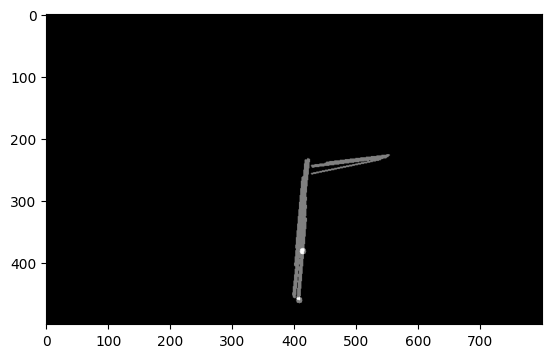

In [ ]:
test = np.zeros(result.shape, dtype=np.uint8)
cv.circle(test, (int(y_punta_g), int(x_punta_g)), 5, (255,255,255), -1)
cv.circle(test, (int(y_punta), int(x_punta)), 5, (255,255,255), -1)

plt.imshow(test+lines_clock, cmap="gray")